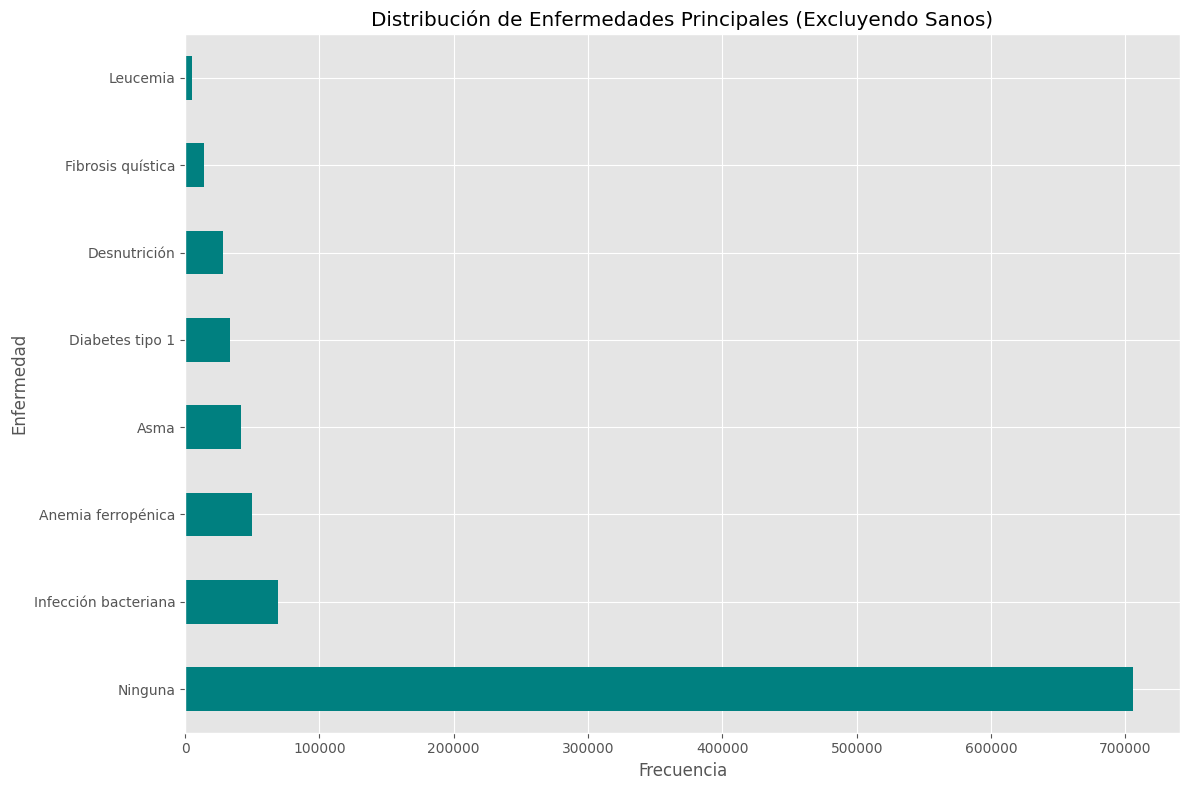


Resumen estadístico de características clave:
             Hb_g/dL          Hto_%  Glóbulos_Rojos_mill/µL         VCM_fL  \
count  947053.000000  947053.000000           947053.000000  947053.000000   
mean       12.803682      38.440889                4.680180      87.822366   
std         1.752384       4.560907                0.385122       8.601420   
min         5.500000      19.800000                3.800000      54.600000   
25%        12.100000      36.290000                4.370000      83.470000   
50%        13.060000      38.720000                4.690000      88.820000   
75%        13.940000      41.290000                4.980000      94.150000   
max        16.000000      48.000000                5.500000     100.000000   

           HDL_mg/dL  
count  947053.000000  
mean       52.500950  
std         6.299718  
min        40.000000  
25%        47.490000  
50%        52.490000  
75%        57.510000  
max        65.000000  

Reporte de Clasificación:
                

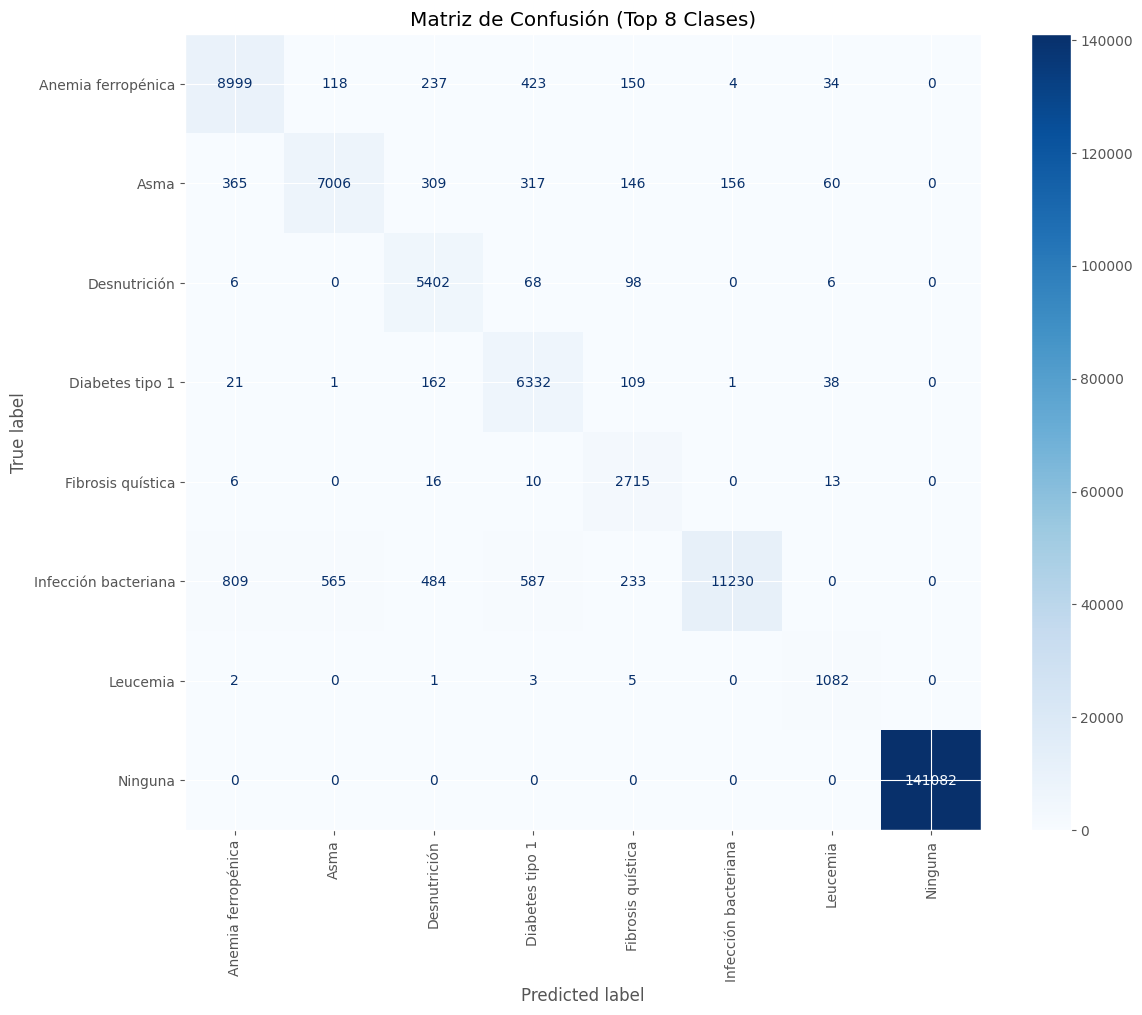

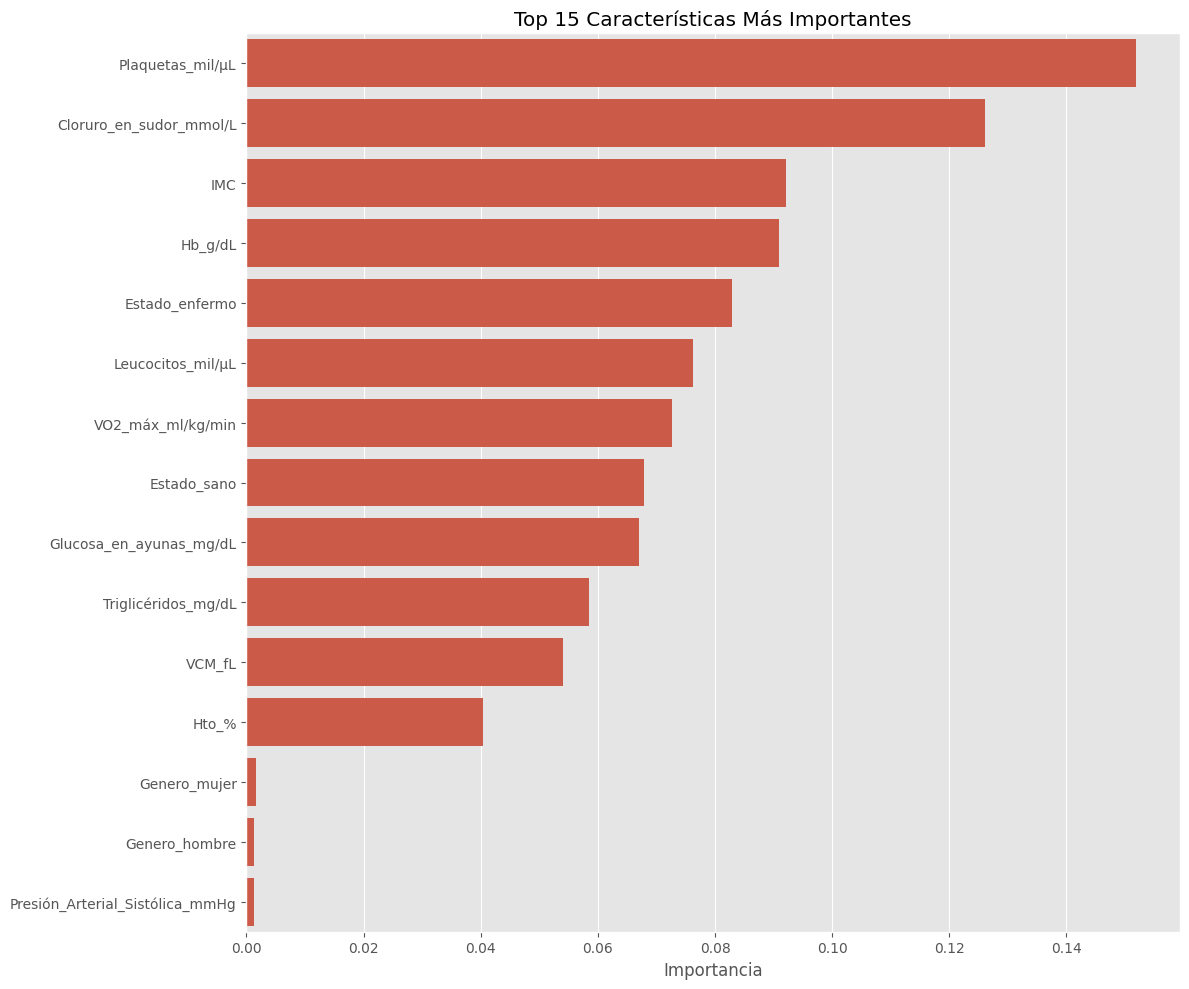


Vista previa del DataFrame con 'pred_enfermedad':
   Enfermedad_Principal       pred_enfermedad
0               Ninguna               Ninguna
1               Ninguna               Ninguna
2               Ninguna               Ninguna
3  Infección bacteriana  Infección bacteriana
4               Ninguna               Ninguna

Conteo de registros por Enfermedad (Incluyendo 'Sano'):

Distribución de Enfermedades (Real):
Enfermedad_Principal
Ninguna                 705406
Infección bacteriana     69541
Anemia ferropénica       49824
Asma                     41794
Diabetes tipo 1          33318
Desnutrición             27902
Fibrosis quística        13802
Leucemia                  5466
Name: count, dtype: int64

Distribución de Enfermedades (Predicha):
pred_enfermedad
Ninguna                 705406
Infección bacteriana     58062
Anemia ferropénica       51483
Asma                     38584
Diabetes tipo 1          38087
Desnutrición             32770
Fibrosis quística        16695
Leucemia

<Figure size 1200x800 with 0 Axes>

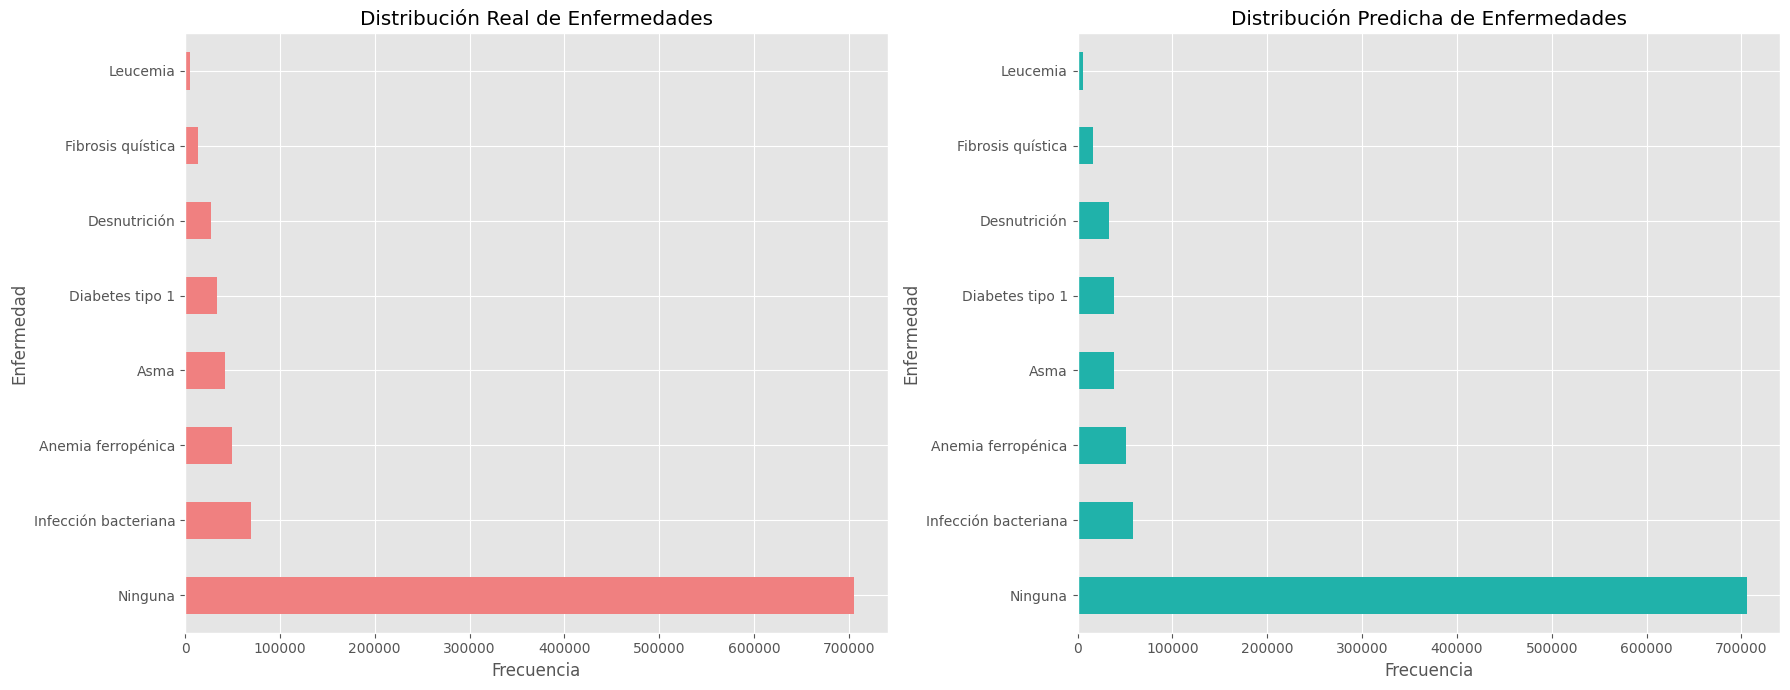


INFORME DEL MODELO PREDICTIVO DE ENFERMEDADES

🔍 **Enfermedades Detectables** (8):
Todas las clases identificadas por el modelo son: Anemia ferropénica, Asma, Desnutrición, Diabetes tipo 1, Fibrosis quística, Infección bacteriana, Leucemia, Ninguna

📊 **Métricas Clave del Modelo**:
- **Precisión General del Modelo**: 97.06%

- **Reporte de Clasificación Detallado (para columna 'Enfermedad_Principal')**:
                      precision    recall  f1-score   support

  Anemia ferropénica       0.88      0.90      0.89      9965
                Asma       0.91      0.84      0.87      8359
        Desnutrición       0.82      0.97      0.89      5580
     Diabetes tipo 1       0.82      0.95      0.88      6664
   Fibrosis quística       0.79      0.98      0.87      2760
Infección bacteriana       0.99      0.81      0.89     13908
            Leucemia       0.88      0.99      0.93      1093
             Ninguna       1.00      1.00      1.00    141082

            accuracy            

In [4]:
# -*- coding: utf-8 -*-
"""Análisis Predictivo de Enfermedades con Random Forest"""
# Instalar librerías necesarias
!pip install shap > /dev/null

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import joblib
import logging
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import shap

# Configuración
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

# =============================================
# 1. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# =============================================
logger.info("Cargando y analizando datos...")

# Cargar dataset
try:
    df = pd.read_csv('pacientes_01.csv')
    logger.info(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
except Exception as e:
    logger.error(f"Error al cargar el dataset: {str(e)}")
    raise

# Columnas requeridas para el modelo
REQUIRED_FEATURES = [
    'Hb_g/dL', 'Hto_%', 'Glóbulos_Rojos_mill/µL', 'VCM_fL', 'HDL_mg/dL',
    'LDL_mg/dL', 'Glucosa_en_ayunas_mg/dL', 'Leucocitos_mil/µL',
    'Plaquetas_mil/µL', 'VO2_máx_ml/kg/min', 'FC_máx_alcanzada_lpm',
    'Presión_Arterial_Sistólica_mmHg', 'Presión_Arterial_Diastólica_mmHg',
    'IMC', 'CHCM_g/dL', 'Presión_sistólica_post_esfuerzo_mmHg',
    'HRR_descenso_en_1_min', 'Cloruro_en_sudor_mmol/L', 'Volumen_de_sudor_mg',
    'Na_mmol/L', 'K_mmol/L', 'Colesterol_Total_mg/dL', 'Triglicéridos_mg/dL'
]

# Verificar columnas requeridas
for col in REQUIRED_FEATURES:
    if col not in df.columns:
        df[col] = 0.0
        logger.warning(f"Columna requerida '{col}' no encontrada. Se añadió con valor 0.")

# Preprocesamiento de enfermedades
# Asegurarse de que la columna 'Enfermedades' no sea nula antes de aplicar split
df['Enfermedades_Lista'] = df['Enfermedades'].apply(
    lambda x: x.split(';') if isinstance(x, str) and ';' in x else ([x] if isinstance(x, str) else []))

df['Enfermedad_Principal'] = df['Enfermedades_Lista'].apply(
    lambda x: x[0].strip() if x else 'Sano') # Cambiado 'Ninguna' a 'Sano'

# Análisis de distribución de enfermedades
enfermedades_counts = df[df['Enfermedad_Principal'] != 'Sano']['Enfermedad_Principal'].value_counts()
plt.figure(figsize=(12, 8))
enfermedades_counts.plot(kind='barh', color='teal')
plt.title('Distribución de Enfermedades Principales (Excluyendo Sanos)')
plt.xlabel('Frecuencia')
plt.ylabel('Enfermedad')
plt.tight_layout()
plt.show()

print("\nResumen estadístico de características clave:")
print(df[REQUIRED_FEATURES[:5]].describe())

# =============================================
# 2. PREPARACIÓN DE DATOS
# =============================================
logger.info("Preparando datos para el modelo...")

# Separar características y etiqueta
# Ahora usaremos todo el dataframe y trataremos 'Sano' como una clase más
X = df.drop(columns=[
    'PacienteID', 'RUT', 'Nombre', 'FechaNacimiento',
    'FechaAtencion', 'Enfermedades', 'Enfermedades_Lista', 'Enfermedad_Principal'
])

y = df['Enfermedad_Principal']

# Codificar variable objetivo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Identificar tipos de características
categorical_features = ['Estado', 'Genero']
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# =============================================
# 3. ENTRENAMIENTO DEL MODELO
# =============================================
logger.info("Entrenando modelo Random Forest...")

# Configuración mejorada del modelo
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=3,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        bootstrap=True,
        oob_score=True
    ))
])

model.fit(X_train, y_train)
logger.info("Entrenamiento completado")

# =============================================
# 4. EVALUACIÓN DEL MODELO
# =============================================
# Evaluación básica
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
logger.info(f"Precisión del modelo: {accuracy:.4f}")

# Reporte completo
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
# Ajustar el número de etiquetas a mostrar en la matriz de confusión
max_labels_to_show = 15 # Puedes ajustar este número
display_labels = label_encoder.classes_
if len(display_labels) > max_labels_to_show:
    # Seleccionar las N primeras etiquetas o las más frecuentes si fuera necesario
    display_labels = display_labels[np.argsort(np.bincount(y_test))[-max_labels_to_show:][::-1]] # Top N más frecuentes en y_test

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=90)
plt.title(f'Matriz de Confusión (Top {len(display_labels)} Clases)')
plt.tight_layout()
plt.show()

# =============================================
# 5. ANÁLISIS DEL MODELO
# =============================================
# 5.1 Importancia de características
# Ajustar preprocessor con el conjunto de datos completo para obtener todos los nombres de características
preprocessor.fit(X) # Usar X completo para los nombres de características

# Generar nombres de características después del preprocesamiento
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = list(cat_feature_names) + numeric_features

importances = model.named_steps['classifier'].feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 10))
sns.barplot(x=importances[sorted_idx][:15], y=np.array(feature_names)[sorted_idx][:15])
plt.title('Top 15 Características Más Importantes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# 5.2 Análisis SHAP para interpretabilidad
try:
    logger.info("Calculando valores SHAP (puede tomar tiempo)...")

    # Preparar datos preprocesados
    X_shap_sample = preprocessor.transform(X_test.sample(min(200, len(X_test)), random_state=42)) # Muestra reducida para rendimiento
    explainer = shap.TreeExplainer(model.named_steps['classifier'])
    shap_values = explainer.shap_values(X_shap_sample)

    # Visualización para una clase específica (ej: la primera enfermedad/clase)
    if len(label_encoder.classes_) > 0:
        # Encontrar el índice de la clase 'Sano' para mostrarla primero o de una enfermedad representativa
        sano_idx = np.where(label_encoder.classes_ == 'Sano')[0]
        if len(sano_idx) > 0:
            class_to_display_idx = sano_idx[0]
        else:
            class_to_display_idx = 0 # Si 'Sano' no existe, toma la primera clase

        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values[class_to_display_idx], X_shap_sample,
                             feature_names=feature_names,
                             class_names=label_encoder.classes_,
                             plot_type='bar', max_display=15, show=False) # show=False para controlar la figura
        plt.title(f'Importancia SHAP Promedio para la Clase: {label_encoder.classes_[class_to_display_idx]}')
        plt.tight_layout()
        plt.show()

    # SHAP global summary plot (dot plot)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names,
                      class_names=label_encoder.classes_, show=False)
    plt.title('Impacto SHAP de las Características en la Predicción General')
    plt.tight_layout()
    plt.show()

except Exception as e:
    logger.warning(f"Error en cálculo SHAP: {str(e)}. SHAP requiere un estimador que soporte `tree_path_dependence` o un `masker` apropiado.")

# =============================================
# 6. GENERAR COLUMNA "pred_enfermedad"
# =============================================
logger.info("Generando columna 'pred_enfermedad' para todos los registros...")

# Predecir sobre todo el dataset original (X)
# Primero, transformar todo el dataset X con el preprocessor entrenado
X_processed_full = preprocessor.transform(X)
y_pred_full_encoded = model.named_steps['classifier'].predict(X_processed_full)
df['pred_enfermedad'] = label_encoder.inverse_transform(y_pred_full_encoded)

logger.info("Columna 'pred_enfermedad' creada exitosamente.")
print("\n" + "="*80)
print("Vista previa del DataFrame con 'pred_enfermedad':")
print("="*80)
print(df[['Enfermedad_Principal', 'pred_enfermedad']].head())

# =============================================
# 7. CONTEO DE ENFERMEDADES (INCLUYENDO SANOS)
# =============================================
print("\n" + "="*80)
print("Conteo de registros por Enfermedad (Incluyendo 'Sano'):")
print("="*80)
enfermedades_conteo_real = df['Enfermedad_Principal'].value_counts()
print("\nDistribución de Enfermedades (Real):")
print(enfermedades_conteo_real)

print("\nDistribución de Enfermedades (Predicha):")
enfermedades_conteo_predicha = df['pred_enfermedad'].value_counts()
print(enfermedades_conteo_predicha)

# Visualización del conteo de enfermedades (real vs. predicha)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

enfermedades_conteo_real.plot(kind='barh', ax=axes[0], color='lightcoral')
axes[0].set_title('Distribución Real de Enfermedades')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Enfermedad')

enfermedades_conteo_predicha.plot(kind='barh', ax=axes[1], color='lightseagreen')
axes[1].set_title('Distribución Predicha de Enfermedades')
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('Enfermedad')

plt.tight_layout()
plt.show()

# =============================================
# 8. GUARDADO DEL MODELO
# =============================================
model_path = 'modelo_enfermedades_actualizado.pkl'
joblib.dump({
    'model': model,
    'label_encoder': label_encoder,
    'feature_columns': X.columns.tolist(),
    'accuracy': accuracy,
    'feature_importances': importances,
    'class_names': label_encoder.classes_
}, model_path)

logger.info(f"Modelo exportado exitosamente como '{model_path}'")

# =============================================
# 9. INFORME FINAL
# =============================================
print("\n" + "="*80)
print("INFORME DEL MODELO PREDICTIVO DE ENFERMEDADES")
print("="*80)
print(f"\n🔍 **Enfermedades Detectables** ({len(label_encoder.classes_)}):")
print(f"Todas las clases identificadas por el modelo son: {', '.join(label_encoder.classes_)}")

print("\n📊 **Métricas Clave del Modelo**:")
print(f"- **Precisión General del Modelo**: {accuracy:.2%}")
print("\n- **Reporte de Clasificación Detallado (para columna 'Enfermedad_Principal')**:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Calcular precisión por clase (diagonal de la matriz de confusión normalizada)
# Esto indica qué tan bien el modelo predijo cada clase
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
accuracies_per_class = np.nan_to_num(cm_normalized.diagonal()) # Manejar NaN si una fila es todo ceros

if len(label_encoder.classes_) > 0:
    best_detected_class_idx = np.argmax(accuracies_per_class)
    worst_detected_class_idx = np.argmin(accuracies_per_class)
    print(f"- Clase mejor predicha: '{label_encoder.classes_[best_detected_class_idx]}' (Precisión: {accuracies_per_class[best_detected_class_idx]:.2%})")
    print(f"- Clase peor predicha: '{label_encoder.classes_[worst_detected_class_idx]}' (Precisión: {accuracies_per_class[worst_detected_class_idx]:.2%})")


print("\n💡 **Características Más Influyentes para Predecir Enfermedades**:")
print("Estas características han sido identificadas como las de mayor impacto en las predicciones del modelo:")
for i, idx in enumerate(sorted_idx[:10]): # Top 10 influyentes
    print(f"  {i+1}. **{feature_names[idx]}** (Importancia: {importances[idx]:.4f})")
print("Se recomienda revisar los gráficos de Importancia de Características y SHAP para una visualización detallada.")


print("\n📈 **Conteo de Registros por Enfermedad (Incluyendo 'Sanos')**:")
print("Esta sección muestra la distribución de las enfermedades en tus datos, tanto reales como las predichas por el modelo.")
print("\n**Conteo de Enfermedades Real (Columna 'Enfermedad_Principal'):**")
print(enfermedades_conteo_real.to_string()) # to_string() para mostrar todo el dataframe

print("\n**Conteo de Enfermedades Predicha (Columna 'pred_enfermedad'):**")
print(enfermedades_conteo_predicha.to_string()) # to_string() para mostrar todo el dataframe


print("\n🧠 **Tipo de Modelo**: APRENDIZAJE SUPERVISADO (Clasificación Multiclase)")
print("- **Algoritmo**: Random Forest (Bosque Aleatorio)")
print("- **Estrategia**: Ensamble de múltiples árboles de decisión para mejorar la robustez y precisión.")
print("- **Mecanismo**: Cada árbol en el bosque vota por una clase de enfermedad, y la clase con la mayoría de votos se selecciona como la predicción final.")

print("\n⚙️ **Proceso Científico Completo**: Ha abarcado las siguientes etapas clave:")
print("1. **Recolección y Carga de Datos**: Obtención de registros clínicos de pacientes.")
print("2. **Limpieza y Preparación de Datos**: Manejo de valores faltantes y formato de características.")
print("3. **Análisis Exploratorio de Datos (EDA)**: Comprensión de la distribución y relaciones en los datos.")
print("4. **Ingeniería de Características**: Transformación y selección de variables para optimizar el modelo.")
print("5. **Entrenamiento Supervisado del Modelo**: Ajuste del Random Forest a los datos de entrenamiento con validación estratificada.")
print("6. **Evaluación de Métricas de Desempeño**: Cuantificación de la precisión, recall, f1-score y análisis de la matriz de confusión.")
print("7. **Interpretación del Modelo**: Uso de la importancia de características y valores SHAP para entender cómo el modelo toma sus decisiones.")
print("8. **Generación de Predicciones**: Creación de la columna `pred_enfermedad` con las predicciones del modelo para cada paciente.")
print("9. **Guardado del Modelo**: Persistencia del modelo entrenado y sus componentes para su uso futuro.")

print("\n✅ **Proceso Completado Exitosamente**. El modelo está listo para futuras aplicaciones o despliegue.")
print("="*80)